https://www.kaggle.com/competitions/titanic/data?select=train.csv DATASET LINK THAT ARE USED IN THE CODE

MODEL 2 TASK 1

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [13]:
sns.set(style="whitegrid")

In [14]:
df = pd.read_csv("train.csv")
print("Dataset loaded successfully!")
print(f"Original shape: {df.shape}\n")

Dataset loaded successfully!
Original shape: (891, 12)



In [16]:
#Step 3: Drop Unnecessary Columns
# -------------------------
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)
print("Dropped columns: PassengerId, Name, Ticket, Cabin")
print(f"Current shape: {df.shape}\n")

Dropped columns: PassengerId, Name, Ticket, Cabin
Current shape: (891, 8)



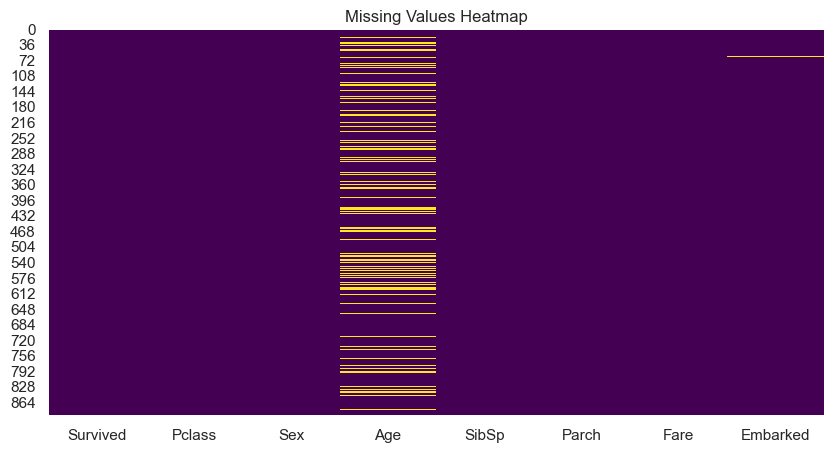

In [17]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [18]:
#Step 5: Handle Missing Values
# -------------------------
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Filled missing values in 'Age' and 'Embarked'\n")


Filled missing values in 'Age' and 'Embarked'



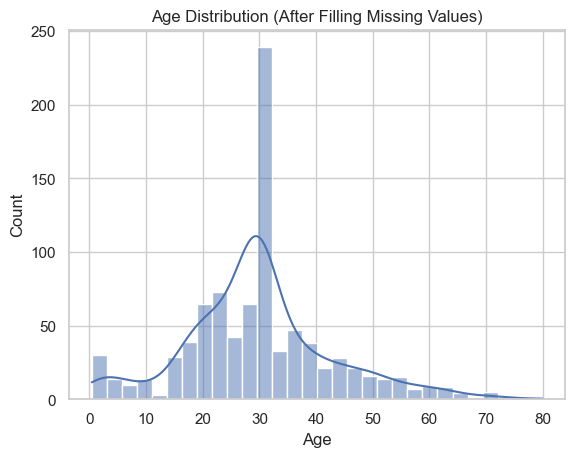

In [19]:
#Step 6: Visualize Distributions Before Outlier Removal
# -------------------------
# Age Distribution
sns.histplot(df['Age'], kde=True, bins=30)
plt.title("Age Distribution (After Filling Missing Values)")
plt.xlabel("Age")
plt.show()

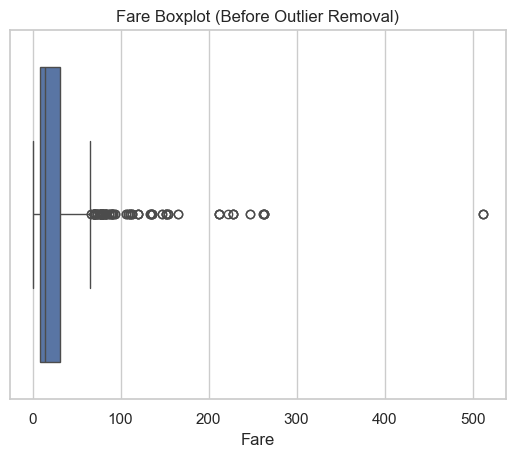

In [20]:
# Fare Boxplot
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot (Before Outlier Removal)")
plt.show()

In [21]:
#Step 7: Remove Outliers Using Z-Score
# -------------------------
df = df[(np.abs(zscore(df[['Age', 'Fare']])) < 3).all(axis=1)]
print("Removed outliers in 'Age' and 'Fare' using Z-score\n")


Removed outliers in 'Age' and 'Fare' using Z-score



In [22]:
#Step 8: Encode Categorical Variables
# -------------------------
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print("Encoded categorical columns: 'Sex' and 'Embarked'\n")


Encoded categorical columns: 'Sex' and 'Embarked'



In [23]:
#Step 9: Scale Numerical Features
# -------------------------
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
print("Scaled 'Age' and 'Fare' using StandardScaler\n")


Scaled 'Age' and 'Fare' using StandardScaler



In [24]:
#Step 10: Define Features and Target
# -------------------------
feature_cols = ['Pclass', 'Age', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X = df[feature_cols]
y = df['Survived']

In [26]:
#Step 11: Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print("Split data into training and testing sets\n")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")


Split data into training and testing sets

X_train shape: (691, 6)
X_test shape: (173, 6)
y_train shape: (691,)
y_test shape: (173,)



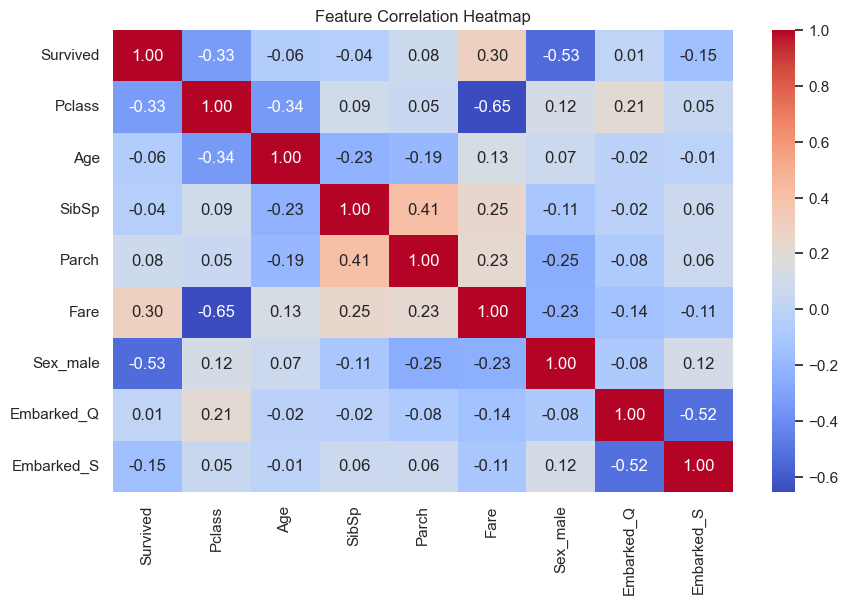

In [28]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

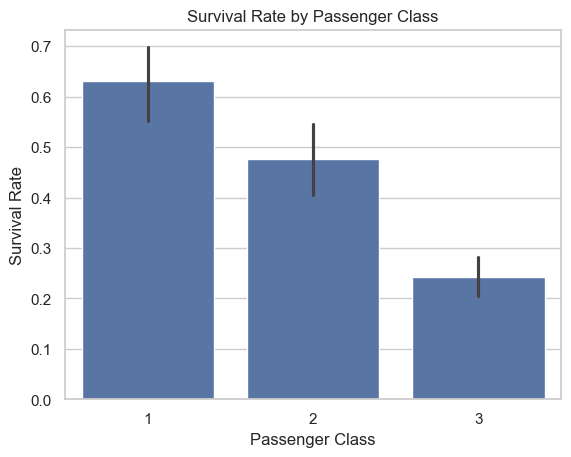

In [29]:
# Survival by Pclass
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


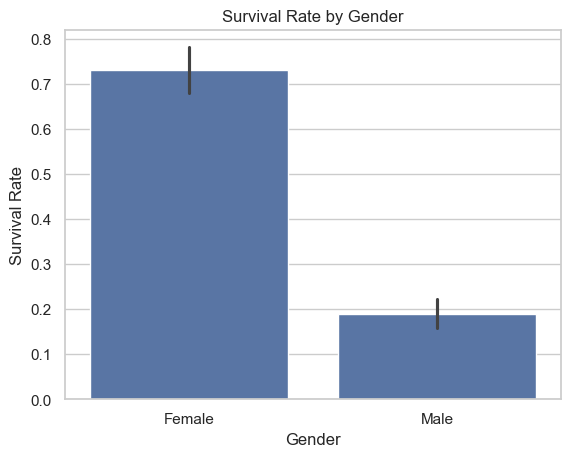

In [30]:
# Survival by Gender
sns.barplot(data=df, x='Sex_male', y='Survived')
plt.title("Survival Rate by Gender")
plt.xticks([0, 1], ['Female', 'Male'])
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

Conclusion of the Code (Data Preprocessing on Titanic Dataset)
This code successfully implements a comprehensive data preprocessing pipeline for the Titanic dataset. The key steps included handling missing values, removing outliers, encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

By visualizing missing data and distributions, we gained a deeper understanding of the dataset and ensured data quality before applying any machine learning algorithms. The preprocessing not only made the dataset cleaner and more structured but also ready for predictive modeling.

Output Conclusion / Insights from the Process



1. **Missing Values**:
   - The dataset had missing values in `Age` and `Embarked`.
   - These were successfully filled using mean (for `Age`) and mode (for `Embarked`) to maintain data consistency.

2. **Outlier Removal**:
   - Extreme values in `Age` and `Fare` were removed using z-score filtering (|z| < 3), which helped reduce skewness in the distribution and improve data quality.

3. **Encoding and Scaling**:
   - Categorical variables like `Sex` and `Embarked` were encoded using one-hot encoding.
   - Numerical features like `Age` and `Fare` were standardized using `StandardScaler`, resulting in better performance for most ML algorithms.

4. **Correlation Heatmap**:
   - Strong correlation observed between `Sex_male` and `Survived`, indicating that **females had a higher chance of survival**.
   - `Pclass` also showed a meaningful impact, with **higher-class passengers more likely to survive**.

5. **Visual Patterns of Survival**:
   - Survival rates were **higher in 1st class** and **lower in 3rd class**.
   - **Females had significantly better survival rates** compared to males — aligning with the known "women and children first" protocol.

6. **Train-Test Split**:
   - The dataset was successfully split into training (80%) and testing (20%) sets with stratification to maintain class balance.
